# AI药物设计第4课 - 线性回归的数学原理

## 学习目标
1. 理解线性回归的四个核心步骤：前向传播、损失计算、梯度计算、参数更新
2. 掌握从一元到多元线性回归的统一思路
3. 应用线性回归预测药物分子性质

## 1. 导入必要的库

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import rcParams

# 设置中文字体
rcParams['font.sans-serif'] = ['SimHei']
rcParams['axes.unicode_minus'] = False

# 设置随机种子
np.random.seed(42)

## 2. 一元线性回归 - 房价预测

### 核心概念
- **模型**: y = wx + b
- **四个步骤**: 前向传播 → 损失计算 → 梯度计算 → 参数更新

In [2]:
# 准备训练数据：房屋面积 → 房价
X = np.array([80, 120, 150])    # 面积(平方米)
y = np.array([100, 160, 185])   # 价格(万元)

# 初始化参数
w = 0.5  # 权重
b = 0.0  # 偏置
learning_rate = 0.00001
epochs = 100

# 记录损失
losses = []

print("一元线性回归训练过程")
print("=" * 50)

for epoch in range(epochs):
    # 步骤1: 前向传播 - 计算预测值
    y_pred = w * X + b
    
    # 步骤2: 损失计算 - MSE
    loss = np.mean((y_pred - y) ** 2)
    losses.append(loss)
    
    # 步骤3: 梯度计算
    dw = np.mean(2 * (y_pred - y) * X)  # ∂L/∂w
    db = np.mean(2 * (y_pred - y))       # ∂L/∂b
    
    # 步骤4: 参数更新
    w = w - learning_rate * dw
    b = b - learning_rate * db
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss:8.2f} | w: {w:.4f}, b: {b:.4f}")

print("=" * 50)
print(f"最终参数: w={w:.4f}, b={b:.4f}")
print(f"模型: y = {w:.4f}x + {b:.4f}")

一元线性回归训练过程
Epoch   0 | Loss:  8566.67 | w: 0.7220, b: 0.0018
Epoch  10 | Loss:    39.56 | w: 1.2509, b: 0.0061
Epoch  20 | Loss:    30.18 | w: 1.2684, b: 0.0063
Epoch  30 | Loss:    30.17 | w: 1.2690, b: 0.0064
Epoch  40 | Loss:    30.17 | w: 1.2690, b: 0.0064
Epoch  50 | Loss:    30.17 | w: 1.2690, b: 0.0065
Epoch  60 | Loss:    30.17 | w: 1.2690, b: 0.0066
Epoch  70 | Loss:    30.17 | w: 1.2690, b: 0.0066
Epoch  80 | Loss:    30.17 | w: 1.2690, b: 0.0067
Epoch  90 | Loss:    30.17 | w: 1.2690, b: 0.0067
最终参数: w=1.2690, b=0.0068
模型: y = 1.2690x + 0.0068


### 可视化训练结果

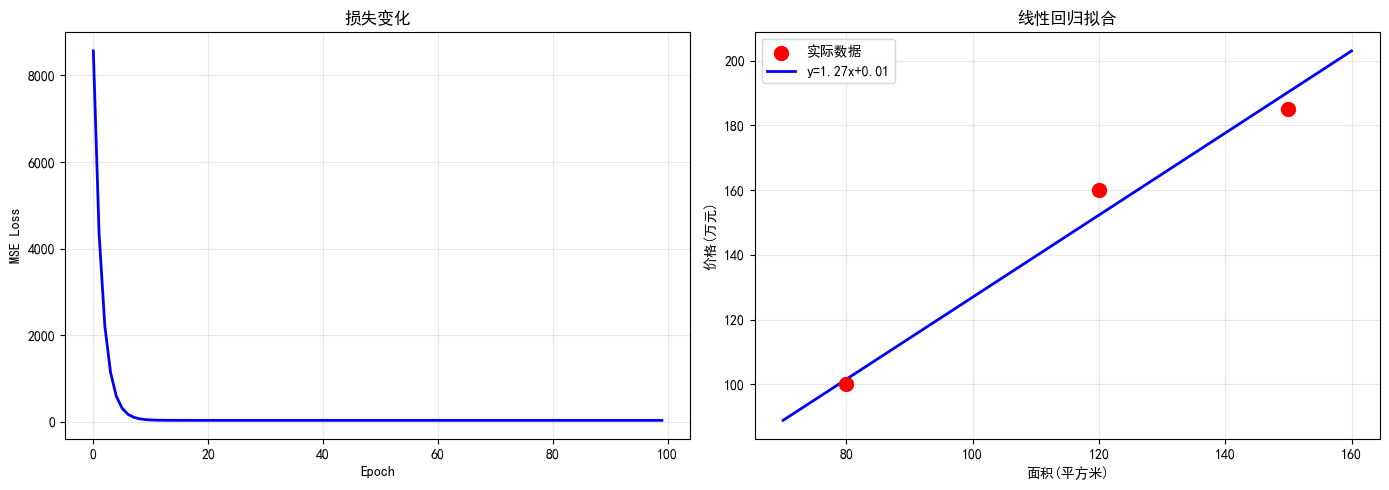

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图: 损失曲线
axes[0].plot(losses, 'b-', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('损失变化')
axes[0].grid(True, alpha=0.3)

# 右图: 拟合结果
axes[1].scatter(X, y, color='red', s=100, label='实际数据', zorder=5)
X_line = np.linspace(70, 160, 100)
y_line = w * X_line + b
axes[1].plot(X_line, y_line, 'b-', linewidth=2, label=f'y={w:.2f}x+{b:.2f}')
axes[1].set_xlabel('面积(平方米)')
axes[1].set_ylabel('价格(万元)')
axes[1].set_title('线性回归拟合')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. 多元线性回归 - 药物分子性质预测

### 核心概念
- **模型**: y = w₁x₁ + w₂x₂ + ... + wₙxₙ + b = X·w + b
- **四个步骤**: 完全相同,只是用矩阵运算

In [4]:
# 准备药物分子数据
drug_data = {
    '药物': ['阿司匹林', '布洛芬', '扑热息痛', '阿莫西林', '头孢拉定'],
    'MW': [180.2, 206.3, 151.2, 365.4, 347.4],      # 分子量
    'LogP': [1.2, 3.5, 0.5, 0.9, -0.4],            # 脂溶性
    'HBD': [1, 1, 2, 4, 3],                         # 氢键供体数
    'PSA': [63.6, 37.3, 49.3, 132.9, 112.7],       # 极性表面积
    '活性': [2.8, 3.5, 2.1, 4.2, 3.8]               # 生物活性
}

df = pd.DataFrame(drug_data)
print("药物分子数据集:")
print(df)

# 准备特征和标签
X = df[['MW', 'LogP', 'HBD', 'PSA']].values
y = df['活性'].values

print(f"\n特征矩阵 X: {X.shape}")
print(f"标签向量 y: {y.shape}")

药物分子数据集:
     药物     MW  LogP  HBD    PSA   活性
0  阿司匹林  180.2   1.2    1   63.6  2.8
1   布洛芬  206.3   3.5    1   37.3  3.5
2  扑热息痛  151.2   0.5    2   49.3  2.1
3  阿莫西林  365.4   0.9    4  132.9  4.2
4  头孢拉定  347.4  -0.4    3  112.7  3.8

特征矩阵 X: (5, 4)
标签向量 y: (5,)


In [5]:
# 特征标准化(帮助收敛)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_norm = (X - X_mean) / X_std

# 初始化参数
n_features = X.shape[1]
w = np.zeros(n_features)  # 权重向量
b = 0.0                    # 偏置
learning_rate = 0.01
epochs = 1000

# 记录损失
losses = []

print("多元线性回归训练过程")
print("=" * 50)

for epoch in range(epochs):
    # 步骤1: 前向传播 - 矩阵乘法
    y_pred = X_norm @ w + b
    
    # 步骤2: 损失计算 - MSE
    loss = np.mean((y_pred - y) ** 2)
    losses.append(loss)
    
    # 步骤3: 梯度计算 - 矩阵运算
    dw = (2/len(y)) * X_norm.T @ (y_pred - y)  # ∂L/∂w
    db = (2/len(y)) * np.sum(y_pred - y)        # ∂L/∂b
    
    # 步骤4: 参数更新
    w = w - learning_rate * dw
    b = b - learning_rate * db
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss:.6f}")

print("=" * 50)
print(f"最终参数:")
print(f"权重 w: {w}")
print(f"偏置 b: {b:.4f}")

多元线性回归训练过程
Epoch    0 | Loss: 11.316000
Epoch  100 | Loss: 0.233104
Epoch  200 | Loss: 0.020158
Epoch  300 | Loss: 0.010089
Epoch  400 | Loss: 0.006475
Epoch  500 | Loss: 0.004285
Epoch  600 | Loss: 0.002900
Epoch  700 | Loss: 0.002014
Epoch  800 | Loss: 0.001439
Epoch  900 | Loss: 0.001059
最终参数:
权重 w: [ 0.73038808  0.35842649 -0.19540391  0.2575456 ]
偏置 b: 3.2800


### 模型评估

In [6]:
# 在训练集上评估
y_pred_final = X_norm @ w + b

print("模型预测结果:")
print("=" * 60)
print(f"{'药物':^10} {'实际活性':^12} {'预测活性':^12} {'误差':^12}")
print("=" * 60)

for i, drug in enumerate(df['药物']):
    print(f"{drug:^10} {y[i]:^12.2f} {y_pred_final[i]:^12.2f} {y_pred_final[i]-y[i]:^12.2f}")

mse = np.mean((y_pred_final - y) ** 2)
rmse = np.sqrt(mse)
print("=" * 60)
print(f"MSE:  {mse:.6f}")
print(f"RMSE: {rmse:.6f}")

模型预测结果:
    药物         实际活性         预测活性          误差     
   阿司匹林        2.80         2.81         0.01    
   布洛芬         3.50         3.48        -0.02    
   扑热息痛        2.10         2.12         0.02    
   阿莫西林        4.20         4.23         0.03    
   头孢拉定        3.80         3.75        -0.05    
MSE:  0.000803
RMSE: 0.028339


### 预测新分子

In [7]:
# 新分子数据
new_molecules = [
    {'名称': '新分子A', 'MW': 200.3, 'LogP': 2.5, 'HBD': 2, 'PSA': 70.1},
    {'名称': '新分子B', 'MW': 350.5, 'LogP': 1.8, 'HBD': 3, 'PSA': 95.2},
]

print("新分子活性预测:")
print("=" * 60)

for mol in new_molecules:
    # 提取特征并标准化
    features = np.array([mol['MW'], mol['LogP'], mol['HBD'], mol['PSA']])
    features_norm = (features - X_mean) / X_std
    
    # 预测
    prediction = features_norm @ w + b
    
    print(f"{mol['名称']}:")
    print(f"  特征: MW={mol['MW']}, LogP={mol['LogP']}, HBD={mol['HBD']}, PSA={mol['PSA']}")
    print(f"  预测活性: {prediction:.2f}")
    print()

新分子活性预测:
新分子A:
  特征: MW=200.3, LogP=2.5, HBD=2, PSA=70.1
  预测活性: 3.22

新分子B:
  特征: MW=350.5, LogP=1.8, HBD=3, PSA=95.2
  预测活性: 4.27



### 可视化结果

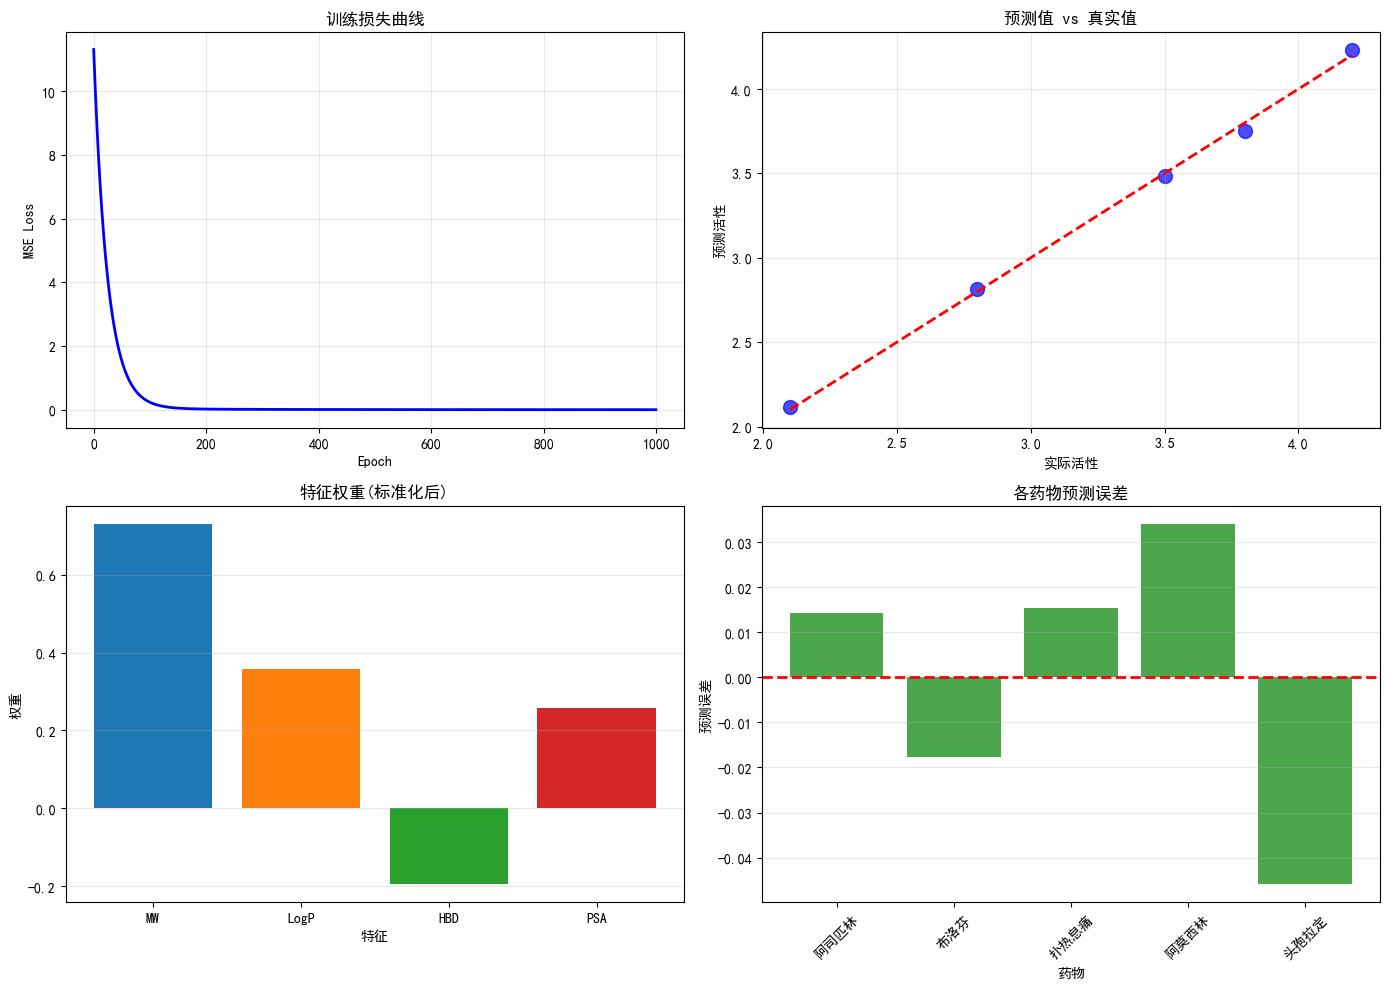

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 损失曲线
axes[0, 0].plot(losses, 'b-', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].set_title('训练损失曲线')
axes[0, 0].grid(True, alpha=0.3)

# 2. 预测 vs 真实
axes[0, 1].scatter(y, y_pred_final, s=100, alpha=0.7, color='blue')
axes[0, 1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
axes[0, 1].set_xlabel('实际活性')
axes[0, 1].set_ylabel('预测活性')
axes[0, 1].set_title('预测值 vs 真实值')
axes[0, 1].grid(True, alpha=0.3)

# 3. 特征权重
feature_names = ['MW', 'LogP', 'HBD', 'PSA']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
axes[1, 0].bar(feature_names, w, color=colors)
axes[1, 0].set_xlabel('特征')
axes[1, 0].set_ylabel('权重')
axes[1, 0].set_title('特征权重(标准化后)')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. 误差分布
errors = y_pred_final - y
axes[1, 1].bar(df['药物'], errors, color='green', alpha=0.7)
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('药物')
axes[1, 1].set_ylabel('预测误差')
axes[1, 1].set_title('各药物预测误差')
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. 学习率对比实验

观察不同学习率对训练的影响

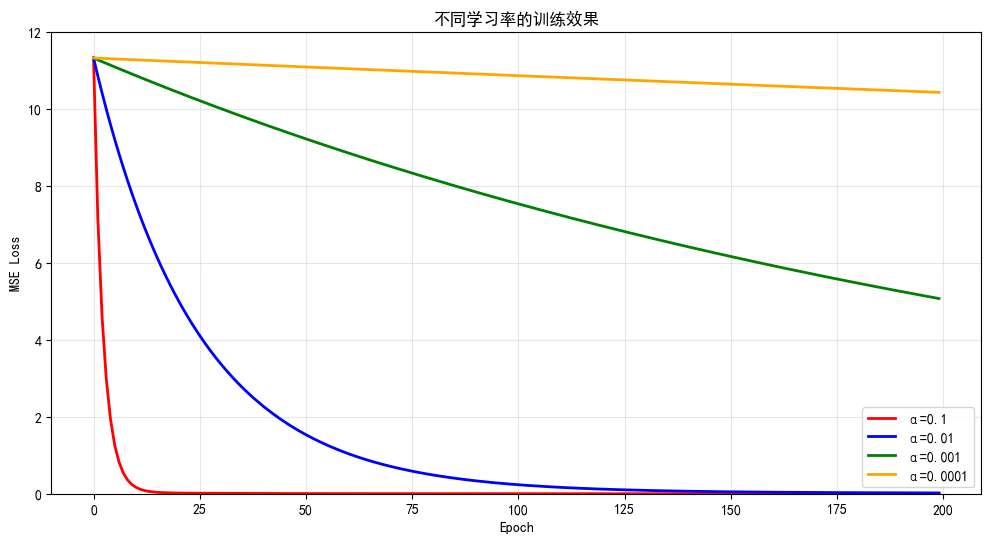

In [9]:
learning_rates = [0.1, 0.01, 0.001, 0.0001]
colors = ['red', 'blue', 'green', 'orange']

plt.figure(figsize=(12, 6))

for lr, color in zip(learning_rates, colors):
    w_temp = np.zeros(n_features)
    b_temp = 0.0
    losses_temp = []
    
    for epoch in range(200):
        # 四个步骤
        y_pred = X_norm @ w_temp + b_temp
        loss = np.mean((y_pred - y) ** 2)
        losses_temp.append(loss)
        
        dw = (2/len(y)) * X_norm.T @ (y_pred - y)
        db = (2/len(y)) * np.sum(y_pred - y)
        
        w_temp = w_temp - lr * dw
        b_temp = b_temp - lr * db
    
    plt.plot(losses_temp, color=color, linewidth=2, label=f'α={lr}')

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('不同学习率的训练效果')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 12)
plt.show()

## 5. 总结

### 线性回归的四个核心步骤

无论是一元还是多元,训练流程都是:

```python
for epoch in range(epochs):
    # 1. 前向传播
    y_pred = X @ w + b
    
    # 2. 损失计算
    loss = mean((y_pred - y)²)
    
    # 3. 梯度计算
    dw = (2/n) * X.T @ (y_pred - y)
    db = (2/n) * sum(y_pred - y)
    
    # 4. 参数更新
    w = w - α * dw
    b = b - α * db
```

### 关键点
- 一元和多元的区别只在于特征维度,核心逻辑完全一致
- 使用矩阵运算,避免循环,代码简洁高效
- 特征标准化有助于加快收敛
- 学习率需要仔细调整

## 6. 课后练习

1. 修改学习率,观察训练效果
2. 添加更多药物数据,测试模型泛化能力
3. 尝试预测其他分子性质(如溶解度)
4. 思考:为什么需要特征标准化?